In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



===== Running GA for KNN =====


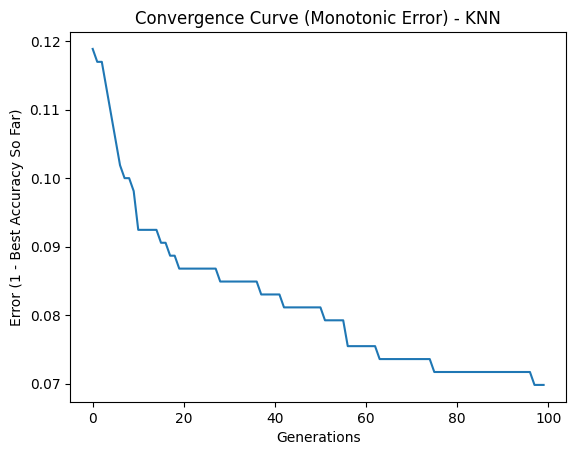

Selected Features: [2, 6, 7, 8, 10, 11, 13, 14, 16, 17, 18, 28, 30, 32, 33]
Without FS: {'Accuracy': 0.8333333333333334, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8787878787878788, 'Precision': 0.5, 'Recall': 0.125, 'F1': 0.2}

===== Running GA for Naive Bayes =====


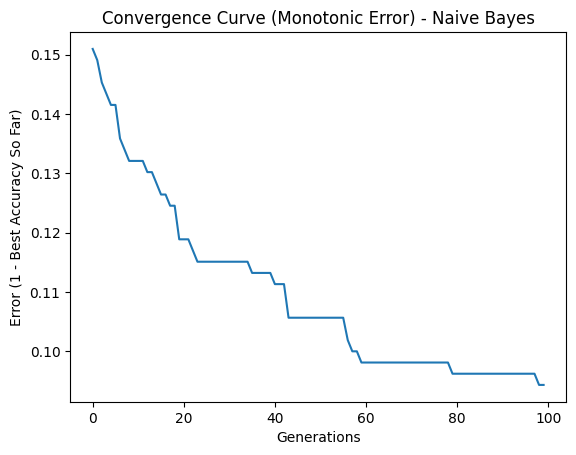

Selected Features: [0, 2, 4, 12, 17, 23, 27, 29, 30]
Without FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}
With FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}

===== Running GA for QDA =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

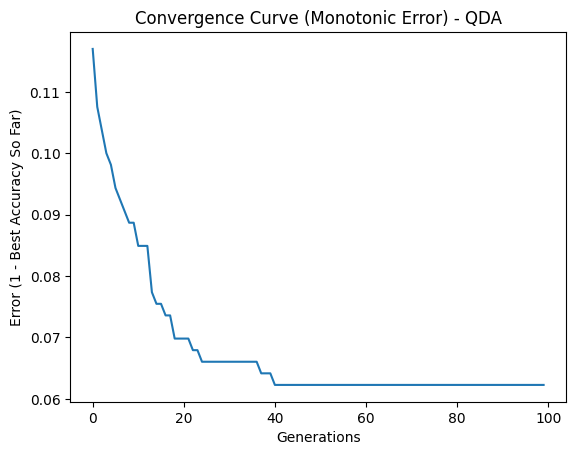

Selected Features: [2, 3, 4, 5, 6, 9, 11, 12, 14, 16, 17, 22, 23, 26, 29, 30, 31, 32, 33, 36, 37]
Without FS: {'Accuracy': 0.8636363636363636, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


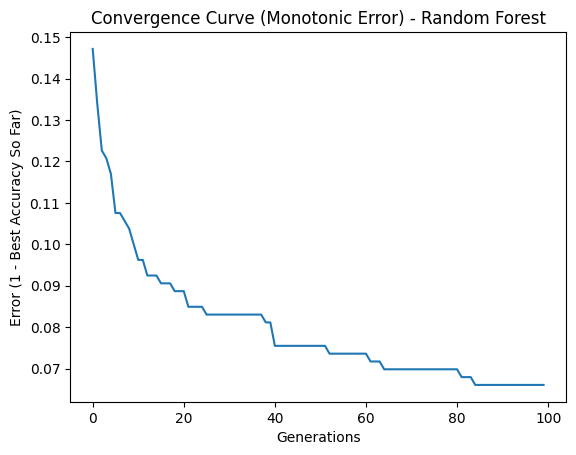

Selected Features: [0, 7, 8, 10, 11, 12, 13, 14, 21, 24, 28, 32, 34, 37]
Without FS: {'Accuracy': 0.8484848484848485, 'Precision': 0.25, 'Recall': 0.125, 'F1': 0.16666666666666666}
With FS: {'Accuracy': 0.7727272727272727, 'Precision': 0.1111111111111111, 'Recall': 0.125, 'F1': 0.11764705882352941}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision  Recall  \
0            KNN          0.833333            0.878788   0.500000   0.125   
1    Naive Bayes          0.803030            0.803030   0.142857   0.125   
2            QDA          0.863636            0.803030   0.142857   0.125   
3  Random Forest          0.848485            0.772727   0.111111   0.125   

         F1  
0  0.200000  
1  0.133333  
2  0.133333  
3  0.117647  


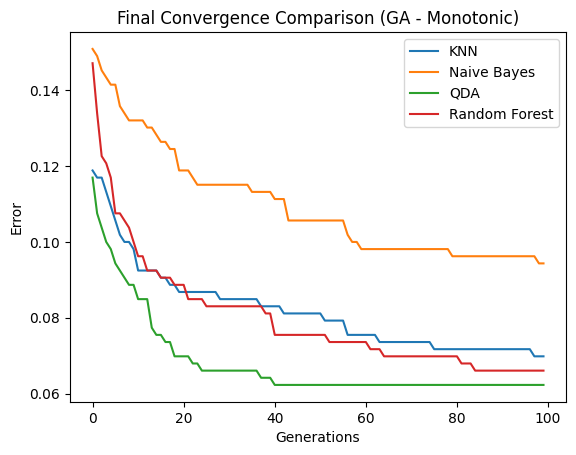


  Avg Execution Time : 844.9617 s
  Avg Memory Used    : 14.0602 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) - CM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-CM1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = []
            for ind in population:
                selected = [i for i in range(len(ind)) if ind[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


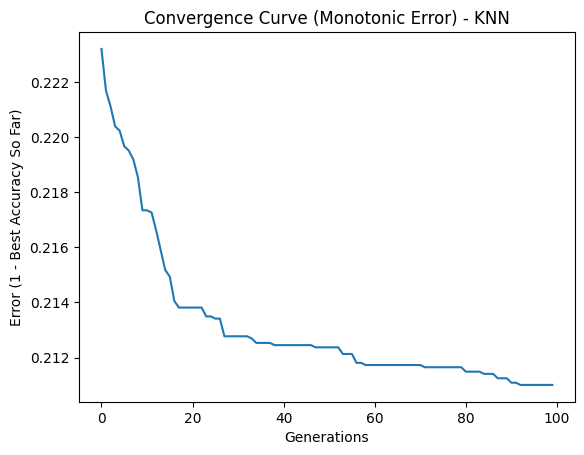

Selected Features: [3, 6, 8, 10, 11, 12, 13, 14, 16, 17, 21]
Without FS: {'Accuracy': 0.7559409120102761, 'Precision': 0.35668789808917195, 'Recall': 0.16716417910447762, 'F1': 0.22764227642276422}
With FS: {'Accuracy': 0.76043673731535, 'Precision': 0.39893617021276595, 'Recall': 0.22388059701492538, 'F1': 0.28680688336520077}

===== Running GA for Naive Bayes =====


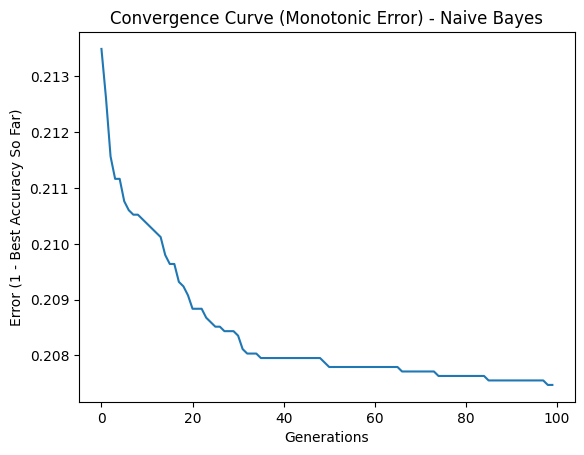

Selected Features: [1, 4, 6, 7, 9, 11, 14, 20, 21]
Without FS: {'Accuracy': 0.7745664739884393, 'Precision': 0.4393939393939394, 'Recall': 0.17313432835820897, 'F1': 0.24839400428265523}
With FS: {'Accuracy': 0.775208734746307, 'Precision': 0.43902439024390244, 'Recall': 0.16119402985074627, 'F1': 0.23580786026200873}

===== Running GA for QDA =====


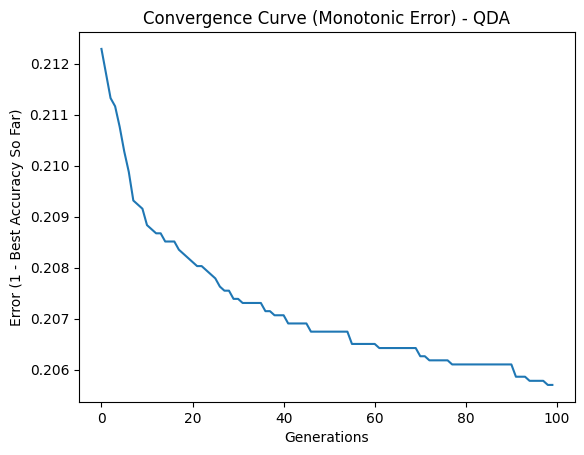

Selected Features: [1, 11, 12, 14, 19]
Without FS: {'Accuracy': 0.7790622992935131, 'Precision': 0.45714285714285713, 'Recall': 0.14328358208955225, 'F1': 0.21818181818181817}
With FS: {'Accuracy': 0.7809890815671162, 'Precision': 0.45714285714285713, 'Recall': 0.0955223880597015, 'F1': 0.1580246913580247}

===== Running GA for Random Forest =====


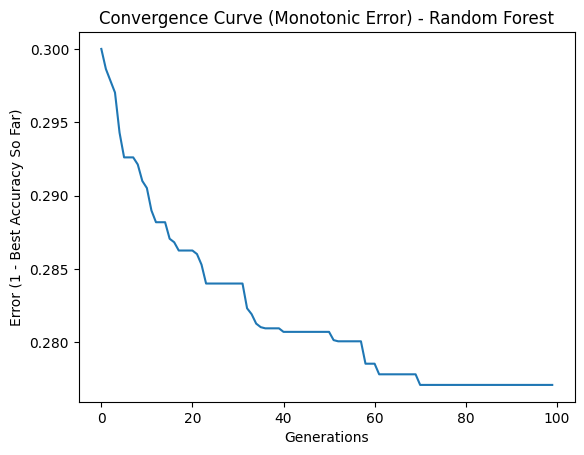

Selected Features: [1, 4, 6, 7, 9, 11, 14, 20, 21]
Without FS: {'Accuracy': 0.6711624919717405, 'Precision': 0.33206831119544594, 'Recall': 0.5223880597014925, 'F1': 0.4060324825986079}
With FS: {'Accuracy': 0.6242774566473989, 'Precision': 0.3059006211180124, 'Recall': 0.5880597014925373, 'F1': 0.4024514811031665}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.755941            0.760437   0.398936  0.223881   
1    Naive Bayes          0.774566            0.775209   0.439024  0.161194   
2            QDA          0.779062            0.780989   0.457143  0.095522   
3  Random Forest          0.671162            0.624277   0.305901  0.588060   

         F1  
0  0.286807  
1  0.235808  
2  0.158025  
3  0.402451  


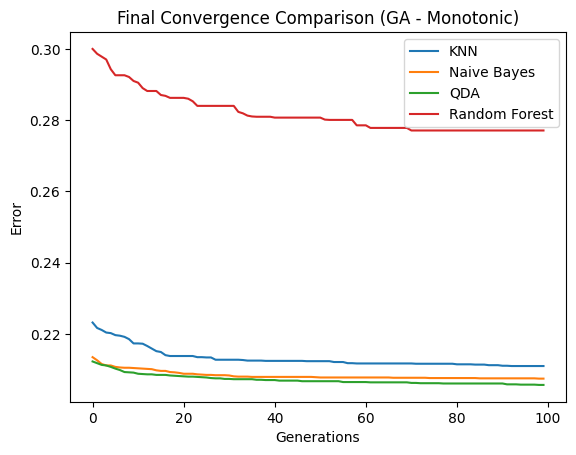


  Avg Execution Time : 1111.9502 s
  Avg Memory Used    : 8.8662 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) - CM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-JM1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = []
            for ind in population:
                selected = [i for i in range(len(ind)) if ind[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


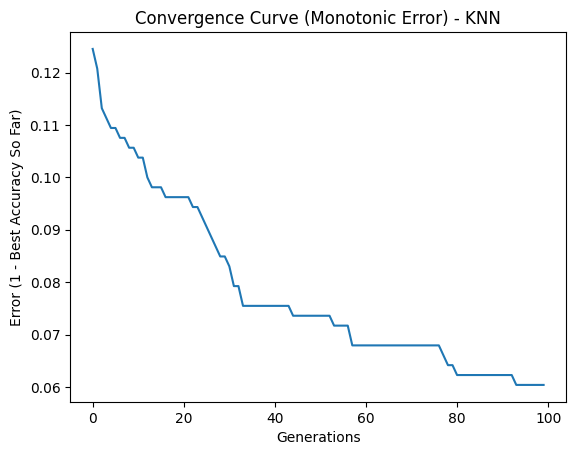

Selected Features: [2, 8, 9, 13, 14, 16, 17, 18, 21, 27, 28, 30, 31, 32, 33, 37]
Without FS: {'Accuracy': 0.8333333333333334, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8636363636363636, 'Precision': 0.4, 'Recall': 0.25, 'F1': 0.3076923076923077}

===== Running GA for Naive Bayes =====


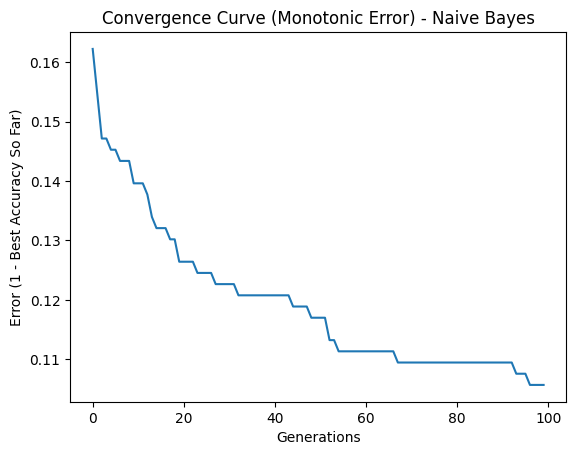

Selected Features: [1, 4, 7, 8, 9, 10, 12, 15, 17, 19, 23, 26, 27, 28, 30]
Without FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}
With FS: {'Accuracy': 0.803030303030303, 'Precision': 0.14285714285714285, 'Recall': 0.125, 'F1': 0.13333333333333333}

===== Running GA for QDA =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

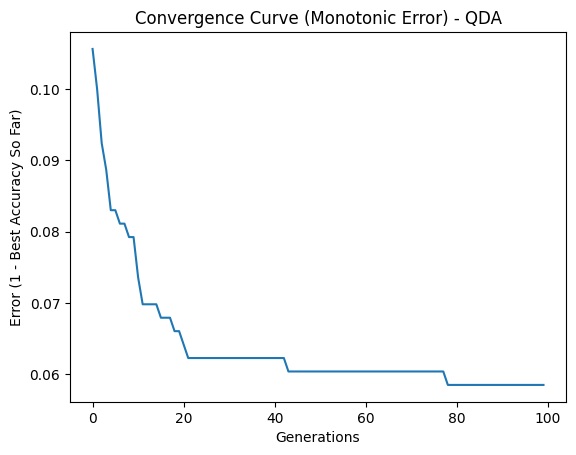

Selected Features: [2, 3, 4, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 23, 25, 26, 27, 32]
Without FS: {'Accuracy': 0.8636363636363636, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
With FS: {'Accuracy': 0.8181818181818182, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


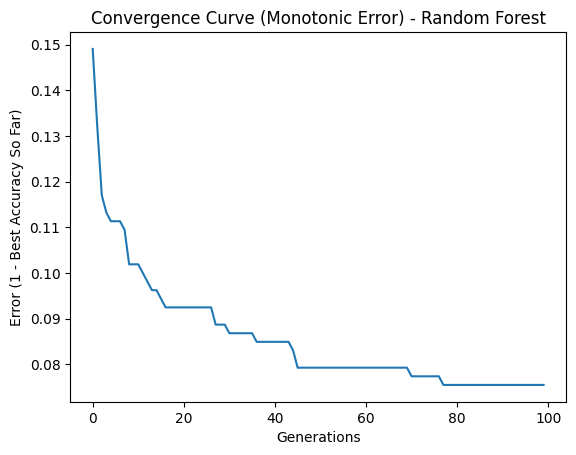

Selected Features: [0, 2, 4, 5, 6, 8, 9, 10, 11, 12, 15, 16, 22, 24, 25, 27, 28, 29, 32, 33, 34, 37]
Without FS: {'Accuracy': 0.8484848484848485, 'Precision': 0.375, 'Recall': 0.375, 'F1': 0.375}
With FS: {'Accuracy': 0.8181818181818182, 'Precision': 0.16666666666666666, 'Recall': 0.125, 'F1': 0.14285714285714285}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision  Recall  \
0            KNN          0.833333            0.863636   0.400000   0.250   
1    Naive Bayes          0.803030            0.803030   0.142857   0.125   
2            QDA          0.863636            0.818182   0.000000   0.000   
3  Random Forest          0.848485            0.818182   0.166667   0.125   

         F1  
0  0.307692  
1  0.133333  
2  0.000000  
3  0.142857  


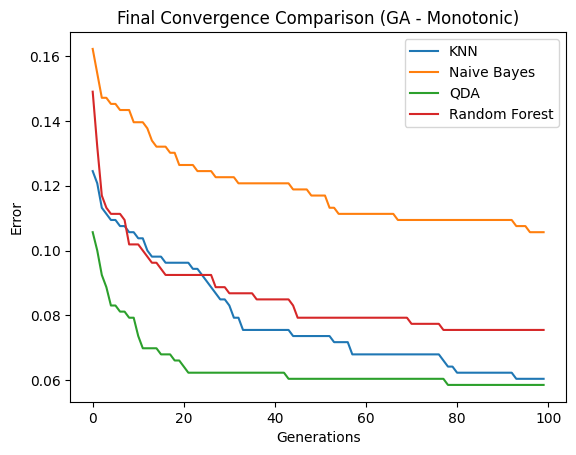


  Avg Execution Time : 809.9293 s
  Avg Memory Used    : 14.0794 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) - CM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-KC1.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = []
            for ind in population:
                selected = [i for i in range(len(ind)) if ind[i] == 1]

                if len(selected) < 3:
                    acc = 0
                else:
                    model.fit(X_train[:, selected], y_train)
                    pred = model.predict(X_val[:, selected])
                    acc = accuracy_score(y_val, pred)

                acc_list.append(acc)

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")


===== Running GA for KNN =====


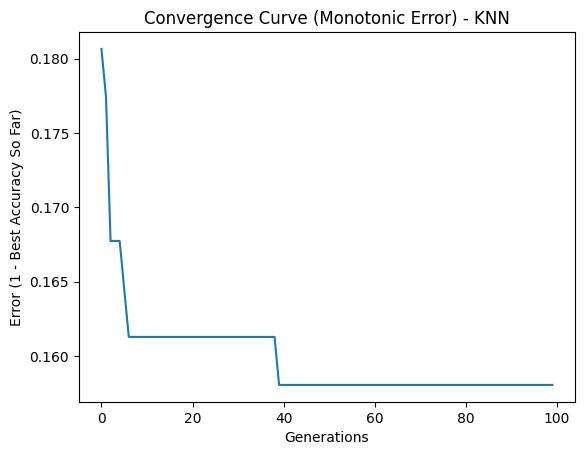

Selected Features: [0, 2, 4, 6, 7, 9, 10, 22, 23, 26, 27, 28, 31, 32, 33, 36, 39]
Without FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.14285714285714285, 'F1': 0.2222222222222222}
With FS: {'Accuracy': 0.7692307692307693, 'Precision': 0.25, 'Recall': 0.14285714285714285, 'F1': 0.18181818181818182}

===== Running GA for Naive Bayes =====


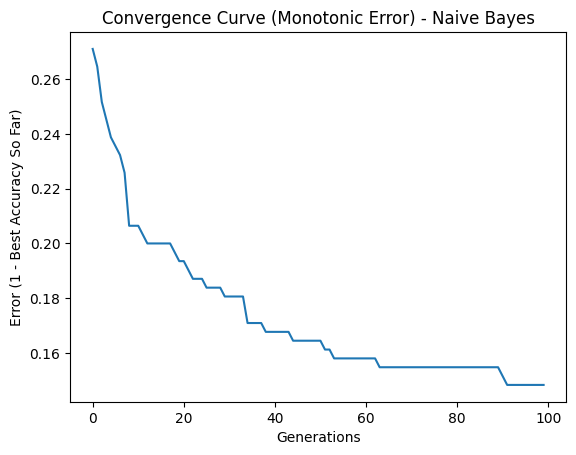

Selected Features: [4, 5, 8, 15, 17, 23, 32, 38]
Without FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.42857142857142855, 'F1': 0.46153846153846156}
With FS: {'Accuracy': 0.8717948717948718, 'Precision': 1.0, 'Recall': 0.2857142857142857, 'F1': 0.4444444444444444}

===== Running GA for QDA =====


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing 

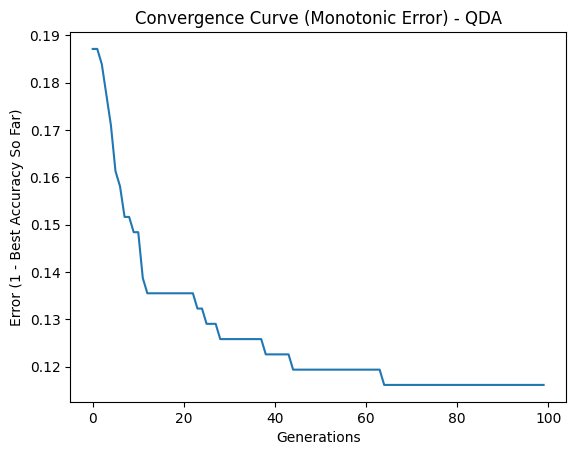

Selected Features: [1, 4, 5, 7, 12, 18, 19, 23, 25, 27, 33, 34]
Without FS: {'Accuracy': 0.8461538461538461, 'Precision': 1.0, 'Recall': 0.14285714285714285, 'F1': 0.25}
With FS: {'Accuracy': 0.8717948717948718, 'Precision': 0.75, 'Recall': 0.42857142857142855, 'F1': 0.5454545454545454}

===== Running GA for Random Forest =====


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


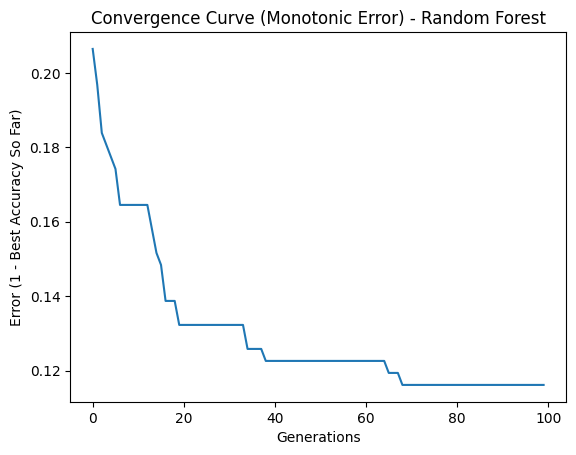

Selected Features: [4, 5, 6, 13, 14, 16, 17, 18, 19, 21, 22, 23, 27, 28, 29, 32, 35, 38]
Without FS: {'Accuracy': 0.8205128205128205, 'Precision': 0.5, 'Recall': 0.14285714285714285, 'F1': 0.2222222222222222}
With FS: {'Accuracy': 0.7692307692307693, 'Precision': 0.3333333333333333, 'Recall': 0.2857142857142857, 'F1': 0.3076923076923077}

===== FINAL RESULT TABLE =====
           Model  Accuracy (No FS)  Accuracy (With FS)  Precision    Recall  \
0            KNN          0.820513            0.769231   0.250000  0.142857   
1    Naive Bayes          0.820513            0.871795   1.000000  0.285714   
2            QDA          0.846154            0.871795   0.750000  0.428571   
3  Random Forest          0.820513            0.769231   0.333333  0.285714   

         F1  
0  0.181818  
1  0.444444  
2  0.545455  
3  0.307692  


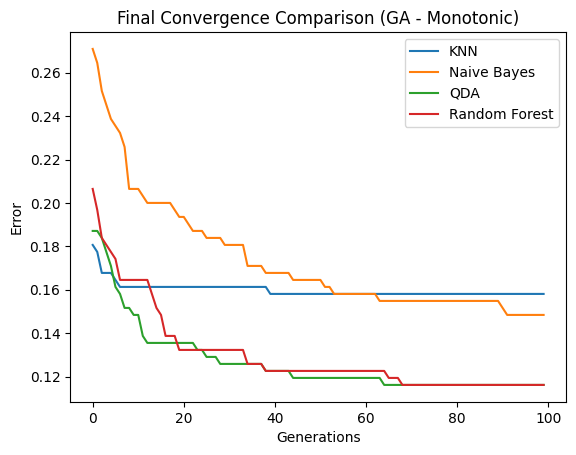


  Avg Execution Time : 809.8981 s
  Avg Memory Used    : 14.5872 MB


In [ ]:
# =========================
# FINAL WRAPPER GA (MONOTONIC CONVERGENCE) - CM1
# =========================

import numpy as np
import pandas as pd
import random
import time
import tracemalloc
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# =========================
# LOAD DATA
# =========================
path = "/content/drive/MyDrive/csv_result-KC3.csv"
df = pd.read_csv(path)

df = df.drop(columns=['name'], errors='ignore')

target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col].map({'N': 0, 'Y': 1})

# =========================
# SPLIT (NO LEAKAGE)
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(
        n_estimators=5,   # ✅ as you asked
        max_depth=5,
        n_jobs=-1,
        class_weight='balanced'
    )
}

# =========================
# GA PARAMETERS
# =========================
POP_SIZE = 10
GENS = 100
REPEATS = 10
MUTATION_RATE = 0.1

num_features = X_train.shape[1]

# =========================
# FITNESS
# =========================
fitness_cache = {}

def fitness(chromosome, model):
    key = tuple(chromosome)

    if key in fitness_cache:
        return fitness_cache[key]

    if sum(chromosome) < 3:
        return 0

    selected = [i for i in range(len(chromosome)) if chromosome[i] == 1]

    X_tr = X_train[:, selected]
    X_v = X_val[:, selected]

    model.fit(X_tr, y_train)
    pred = model.predict(X_v)

    score = accuracy_score(y_val, pred)
    fitness_cache[key] = score

    return score

# =========================
# GA FUNCTIONS
# =========================
def create_population():
    return [np.random.randint(0, 2, num_features) for _ in range(POP_SIZE)]

def roulette_selection(pop, model):
    scores = np.array([fitness(ind, model) for ind in pop])
    total = np.sum(scores)

    if total == 0:
        return random.choice(pop)

    probs = scores / total
    idx = np.random.choice(len(pop), p=probs)
    return pop[idx]

def crossover(p1, p2):
    point = random.randint(1, num_features-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# =========================
# RUN GA
# =========================
results = []
Total_time = []
Total_memory = []
model_curves = {}

for model_name, model in models.items():

    print(f"\n===== Running GA for {model_name} =====")

    tracemalloc.start()
    start_time = time.time()

    best_global = None
    best_score = 0
    all_curves = []

    for r in range(REPEATS):
        population = create_population()
        curve = []
        best_so_far = 0   # 🔥 key

        for gen in range(GENS):

            children = []
            while len(children) < POP_SIZE:
                p1 = roulette_selection(population, model)
                p2 = roulette_selection(population, model)

                child = crossover(p1, p2)
                child = mutate(child)
                children.append(child)

            combined = population + children
            scores = [(fitness(ind, model), ind) for ind in combined]
            scores.sort(reverse=True, key=lambda x: x[0])

            population = [ind for (_, ind) in scores[:POP_SIZE]]

            # 🔥 compute accuracy for convergence
            acc_list = [fitness(ind, model) for ind in population]

            best_acc = max(acc_list)
            best_so_far = max(best_so_far, best_acc)

            curve.append(1 - best_so_far)   # 🔥 error

        all_curves.append(curve)

        best = max(population, key=lambda x: fitness(x, model))
        score = fitness(best, model)

        if score > best_score:
            best_score = score
            best_global = best

    # Time & Memory
    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    Total_time.append(end_time - start_time)
    Total_memory.append(peak / 10**6)

    # Mean curve
    mean_curve = np.mean(all_curves, axis=0)
    model_curves[model_name] = mean_curve

    plt.figure()
    plt.plot(mean_curve)
    plt.title(f"Convergence Curve (Monotonic Error) - {model_name}")
    plt.xlabel("Generations")
    plt.ylabel("Error (1 - Best Accuracy So Far)")
    plt.show()

    # Selected features
    selected_features = [i for i in range(len(best_global)) if best_global[i] == 1]
    if len(selected_features) == 0:
        selected_features = list(range(num_features))

    print("Selected Features:", selected_features)

    # =========================
    # FINAL EVALUATION
    # =========================
    def evaluate(model, X_tr, X_te):
        model.fit(X_tr, y_train_full)
        pred = model.predict(X_te)

        return {
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0)
        }

    res1 = evaluate(model, scaler.transform(X_train_full), X_test)

    X_train_fs = scaler.transform(X_train_full)[:, selected_features]
    X_test_fs = X_test[:, selected_features]

    res2 = evaluate(model, X_train_fs, X_test_fs)

    print("Without FS:", res1)
    print("With FS:", res2)

    results.append([
        model_name,
        res1["Accuracy"], res2["Accuracy"],
        res2["Precision"], res2["Recall"], res2["F1"]
    ])

# =========================
# FINAL TABLE
# =========================
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy (No FS)", "Accuracy (With FS)",
    "Precision", "Recall", "F1"
])

print("\n===== FINAL RESULT TABLE =====")
print(final_df)

# =========================
# FINAL CONVERGENCE GRAPH
# =========================
plt.figure()

for model_name, curve in model_curves.items():
    plt.plot(curve, label=model_name)

plt.title("Final Convergence Comparison (GA - Monotonic)")
plt.xlabel("Generations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# TIME & MEMORY
# =========================
print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")